# Imports and definitions

In [1]:
# imports
from numpy import cos, sin, arctan, sqrt, exp
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from scipy.integrate import simpson
from matplotlib.patches import Arc
from matplotlib import cm, colors
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
from tabulate import tabulate
from copy import deepcopy
from tqdm import tqdm
import numpy as np
import spheroidal
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [3]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl /home/undercover/projects/cactus/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Fetch data

In [ ]:
sd_electric = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0-x0=4.001_h=3")
ts_electric = sd_electric.timeseries
gf_electric = sd_electric.gf

sd_dyonic = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0.25pi-x0=4.001_h=3")
ts_dyonic = sd_dyonic.timeseries
gf_dyonic = sd_dyonic.gf

sd_mag = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0.5pi-x0=4.001_h=3")
ts_mag = sd_mag.timeseries
gf_mag = sd_mag.gf

In [5]:
hor_electric  = sd_electric.horizons
hor1_electric = hor_electric.get_apparent_horizon(1)
hor2_electric = hor_electric.get_apparent_horizon(2)
muls_electric = sd_electric.multipoles

hor_dyonic  = sd_dyonic.horizons
hor1_dyonic = hor_dyonic.get_apparent_horizon(1)
hor2_dyonic = hor_dyonic.get_apparent_horizon(2)
muls_dyonic = sd_dyonic.multipoles

hor_mag  = sd_mag.horizons
hor1_mag = hor_mag.get_apparent_horizon(1)
hor2_mag = hor_mag.get_apparent_horizon(2)
muls_mag = sd_mag.multipoles

# Puncture movement

In [122]:
c1_x_electric = hor1_electric.get_ah_property("centroid_x")
c1_y_electric = hor1_electric.get_ah_property("centroid_y")
c1_z_electric = hor1_electric.get_ah_property("centroid_z")

c2_x_electric = hor2_electric.get_ah_property("centroid_x")
c2_y_electric = hor2_electric.get_ah_property("centroid_y")
c2_z_electric = hor2_electric.get_ah_property("centroid_z")

c1_x_dyonic = hor1_dyonic.get_ah_property("centroid_x")
c1_y_dyonic = hor1_dyonic.get_ah_property("centroid_y")
c1_z_dyonic = hor1_dyonic.get_ah_property("centroid_z")

c2_x_dyonic = hor2_dyonic.get_ah_property("centroid_x")
c2_y_dyonic = hor2_dyonic.get_ah_property("centroid_y")
c2_z_dyonic = hor2_dyonic.get_ah_property("centroid_z")

c1_x_mag = hor1_mag.get_ah_property("centroid_x")
c1_y_mag = hor1_mag.get_ah_property("centroid_y")
c1_z_mag = hor1_mag.get_ah_property("centroid_z")

c2_x_mag = hor2_mag.get_ah_property("centroid_x")
c2_y_mag = hor2_mag.get_ah_property("centroid_y")
c2_z_mag = hor2_mag.get_ah_property("centroid_z")

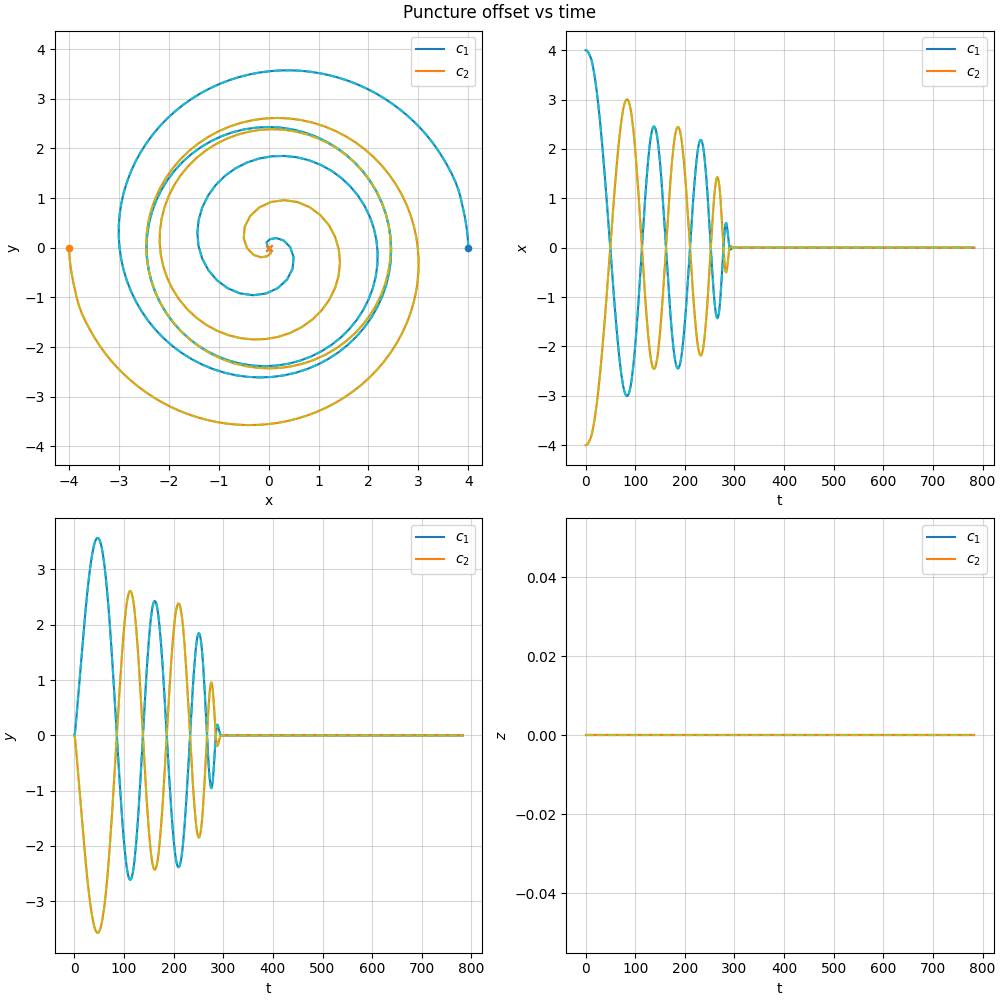

In [123]:
fig, ax = plt.subplots(2, 2, figsize=(10,10), constrained_layout=True)
plt.suptitle("Puncture offset vs time")


ax[0,0].plot(c1_x_electric.values, c1_y_electric.values, color="C0", label=r"$c_1$")
ax[0,0].plot(c2_x_electric.values, c2_y_electric.values, color="C1", label=r"$c_2$")

ax[0,0].plot(c1_x_mag.values, c1_y_mag.values, color="C9", linestyle="dashed")
ax[0,0].plot(c2_x_mag.values, c2_y_mag.values, color="C8", linestyle="dashed")

ax[0,0].scatter([c1_x_electric.values[0]],   [c1_y_electric.values[0]],   color="C0", marker="o", s=20, zorder=10)
ax[0,0].scatter([c2_x_electric.values[0]],   [c2_y_electric.values[0]],   color="C1", marker="o", s=20, zorder=10)
ax[0,0].scatter([c1_x_electric.values[-1]],  [c1_y_electric.values[-1]],  color="C0", marker="x", s=20, zorder=10)
ax[0,0].scatter([c2_x_electric.values[-1]],  [c2_y_electric.values[-1]],  color="C1", marker="x", s=20, zorder=10)

ax[0,0].set_aspect('equal', adjustable='datalim')
ax[0,0].grid(alpha=0.5, zorder=-10)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].legend()


ax[0,1].plot(c1_x_electric.t, c1_x_electric.values, color="C0", label=r"$c_1$")
ax[0,1].plot(c2_x_electric.t, c2_x_electric.values, color="C1", label=r"$c_2$")

ax[0,1].plot(c1_x_mag.t, c1_x_mag.values, color="C9", linestyle="dashed")
ax[0,1].plot(c2_x_mag.t, c2_x_mag.values, color="C8", linestyle="dashed")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_ylabel(r"$x$")
ax[0,1].legend();


ax[1,0].plot(c1_y_electric.t, c1_y_electric.values, color="C0", label=r"$c_1$")
ax[1,0].plot(c2_y_electric.t, c2_y_electric.values, color="C1", label=r"$c_2$")

ax[1,0].plot(c1_y_mag.t, c1_y_mag.values, color="C9", linestyle="dashed")
ax[1,0].plot(c2_y_mag.t, c2_y_mag.values, color="C8", linestyle="dashed")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_ylabel(r"$y$")
ax[1,0].legend();


ax[1,1].plot(c1_z_electric.t, c1_z_electric.values, color="C0", label=r"$c_1$")
ax[1,1].plot(c2_z_electric.t, c2_z_electric.values, color="C1", label=r"$c_2$")

ax[1,1].plot(c1_z_mag.t, c1_z_mag.values, color="C9", linestyle="dashed")
ax[1,1].plot(c2_z_mag.t, c2_z_mag.values, color="C8", linestyle="dashed")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_ylabel(r"$z$")
ax[1,1].legend();

/tmp/ipykernel_765623/1134376018.py:16: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax1.set_yscale("log")


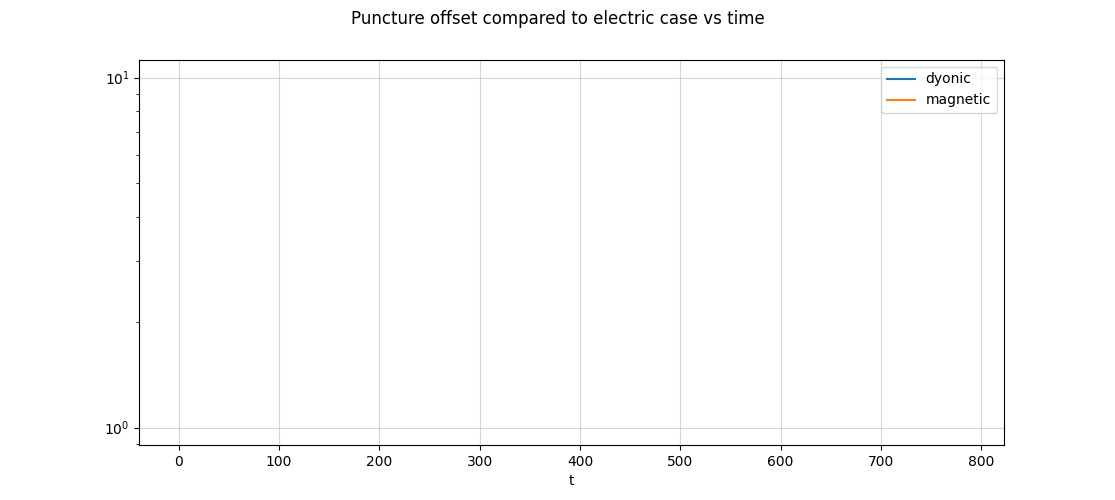

In [124]:
fig, ax1 = plt.subplots(1, 1, figsize=(11.15,5))
plt.suptitle("Puncture offset compared to electric case vs time")

diff_dyonic = sqrt(
    (c1_x_electric.values - c1_x_dyonic.values)**2 + (c1_y_electric.values - c1_y_dyonic.values)**2 + (c1_z_electric.values - c1_z_dyonic.values)**2
)
diff_mag = sqrt(
    (c1_x_electric.values - c1_x_mag.values)**2 + (c1_y_electric.values - c1_y_mag.values)**2 + (c1_z_electric.values - c1_z_mag.values)**2
)

ax1.plot(c1_x_electric.t, diff_dyonic, color="C0", label=r"dyonic")
ax1.plot(c2_x_electric.t, diff_mag,    color="C1", label=r"magnetic")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_yscale("log")
ax1.legend();

# Global quantities

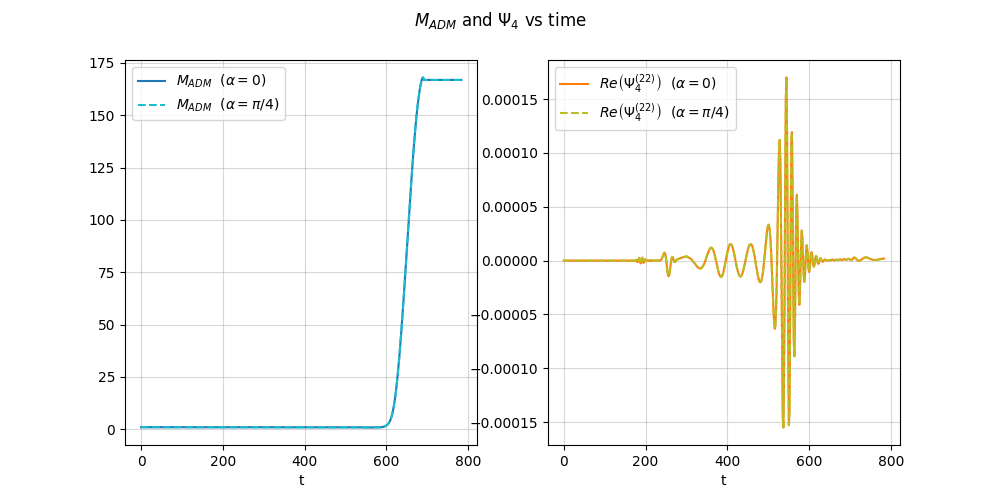

In [9]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$M_{ADM}$ and $\Psi_4$ vs time")

R = 240

M = hor_electric[5,6].adm_energy
psi4_22 = muls_electric["Psi4"][R][(2,2)]

M_dyonic = hor_dyonic[5,6].adm_energy
psi4_22_dyonic = muls_dyonic["Psi4"][R][(2,2)]

ax1.plot(M.t,        M.y,        color="C0", label=r"$M_{ADM}$  $(\alpha = 0)$")
ax1.plot(M_dyonic.t, M_dyonic.y, color="C9", label=r"$M_{ADM}$  $(\alpha = \pi/4)$", linestyle="dashed")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.legend()

ax2.plot(psi4_22.t,        psi4_22.y.real,        color="C1", label=r"$Re \left(\Psi_4^{(22)} \right)$  $(\alpha = 0)$")
ax2.plot(psi4_22_dyonic.t, psi4_22_dyonic.y.real, color="C8", label=r"$Re \left(\Psi_4^{(22)} \right)$  $(\alpha = \pi/4)$", linestyle="dashed")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.legend();

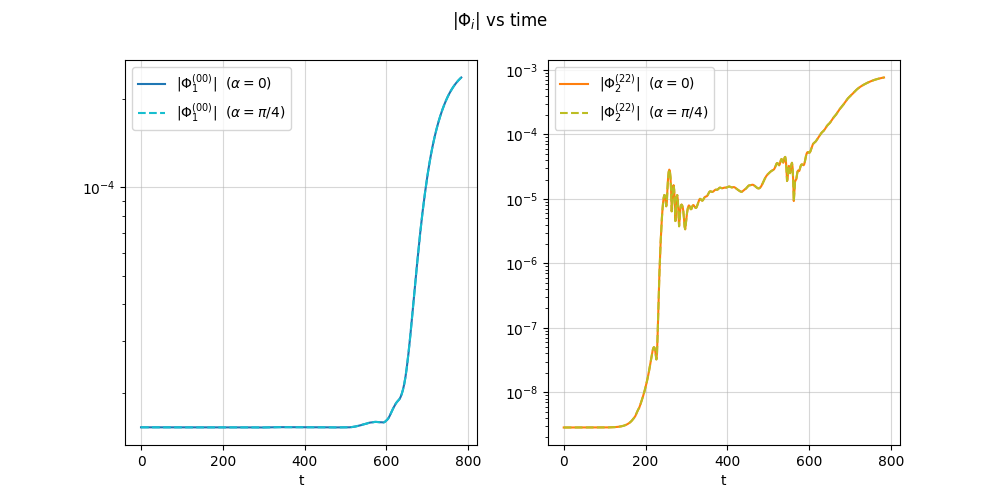

In [10]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$|\Phi_i|$ vs time")

R = 240

Phi1_00 = muls_electric["Phi1"][R][(0,0)]
Phi2_22 = muls_electric["Phi2"][R][(2,2)]

Phi1_00_dyonic = muls_dyonic["Phi1"][R][(0,0)]
Phi2_22_dyonic = muls_dyonic["Phi2"][R][(2,2)]

ax1.plot(Phi1_00.t,        sqrt(Phi1_00.y.real**2 + Phi1_00.y.imag**2),               label=r"$|\Phi_1^{(00)}|$  $(\alpha = 0)$", color="C0")
ax1.plot(Phi1_00_dyonic.t, sqrt(Phi1_00_dyonic.y.real**2 + Phi1_00_dyonic.y.imag**2), label=r"$|\Phi_1^{(00)}|$  $(\alpha = \pi/4)$", color="C9", linestyle="dashed")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_yscale("log")
ax1.legend()

ax2.plot(Phi2_22.t,        sqrt(Phi2_22.y.real**2 + Phi2_22.y.imag**2),               label=r"$|\Phi_2^{(22)}|$  $(\alpha = 0)$", color="C1")
ax2.plot(Phi2_22_dyonic.t, sqrt(Phi2_22_dyonic.y.real**2 + Phi2_22_dyonic.y.imag**2), label=r"$|\Phi_2^{(22)}|$  $(\alpha = \pi/4)$", color="C8", linestyle="dashed")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.set_yscale("log")
ax2.legend();

# EM Radiation

In [31]:
# output frequency is every 128 iterations
n = 230
iteration = 128*n

# α = 0
Ey_electric_gf = gf_electric.x["Ey"].get_iteration(iteration).get_level(0)
coor_gf = Ey_electric_gf.grid.coordinates_1d[0]
Ey_electric = Ey_electric_gf.data

Ez_electric_gf = gf_electric.x["Ez"].get_iteration(iteration).get_level(0)
coor_gf = Ez_electric_gf.grid.coordinates_1d[0]
Ez_electric = Ez_electric_gf.data

By_electric_gf = gf_electric.x["By"].get_iteration(iteration).get_level(0)
coor_gf = By_electric_gf.grid.coordinates_1d[0]
By_electric = By_electric_gf.data

Bz_electric_gf = gf_electric.x["Bz"].get_iteration(iteration).get_level(0)
coor_gf = Bz_electric_gf.grid.coordinates_1d[0]
Bz_electric = Bz_electric_gf.data

# α = π/4
Ey_dyonic_gf = gf_dyonic.x["Ey"].get_iteration(iteration).get_level(0)
coor_gf = Ey_dyonic_gf.grid.coordinates_1d[0]
Ey_dyonic = Ey_dyonic_gf.data

Ez_dyonic_gf = gf_dyonic.x["Ez"].get_iteration(iteration).get_level(0)
coor_gf = Ez_dyonic_gf.grid.coordinates_1d[0]
Ez_dyonic = Ez_dyonic_gf.data

By_dyonic_gf = gf_dyonic.x["By"].get_iteration(iteration).get_level(0)
coor_gf = By_dyonic_gf.grid.coordinates_1d[0]
By_dyonic = By_dyonic_gf.data

Bz_dyonic_gf = gf_dyonic.x["Bz"].get_iteration(iteration).get_level(0)
coor_gf = Bz_dyonic_gf.grid.coordinates_1d[0]
Bz_dyonic = Bz_dyonic_gf.data

# α = π/2
Ey_mag_gf = gf_mag.x["Ey"].get_iteration(iteration).get_level(0)
coor_gf = Ey_mag_gf.grid.coordinates_1d[0]
Ey_mag = Ey_mag_gf.data

Ez_mag_gf = gf_mag.x["Ez"].get_iteration(iteration).get_level(0)
coor_gf = Ez_mag_gf.grid.coordinates_1d[0]
Ez_mag = Ez_mag_gf.data

By_mag_gf = gf_mag.x["By"].get_iteration(iteration).get_level(0)
coor_gf = By_mag_gf.grid.coordinates_1d[0]
By_mag = By_mag_gf.data

Bz_mag_gf = gf_mag.x["Bz"].get_iteration(iteration).get_level(0)
coor_gf = Bz_mag_gf.grid.coordinates_1d[0]
Bz_mag = Bz_mag_gf.data

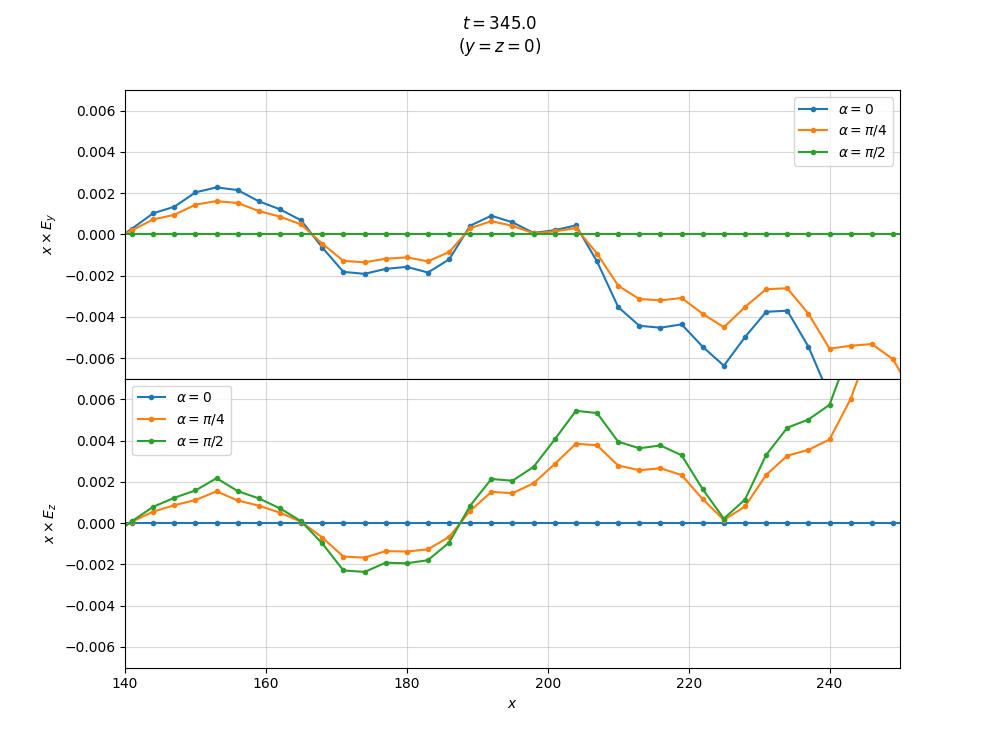

In [32]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10,7.5), sharex=True, gridspec_kw={'hspace': 0})

plt.suptitle(f"$t = {Ey_electric_gf.time}$\n$(y=z=0)$")

# make the plot of y*Ex
ax1.plot(coor_gf, coor_gf*Ey_electric, color="C0", label=r"$\alpha=0$",     marker=".")
ax1.plot(coor_gf, coor_gf*Ey_dyonic,   color="C1", label=r"$\alpha=\pi/4$", marker=".")
ax1.plot(coor_gf, coor_gf*Ey_mag,      color="C2", label=r"$\alpha=\pi/2$", marker=".")

ax1.grid(alpha=0.5)
ax1.set_ylabel(r"$x \times E_y$")
ax1.set_ylim((-0.007,0.007))
ax1.legend()

# make the plot of y*Ez
ax2.plot(coor_gf, coor_gf*Ez_electric, color="C0", label=r"$\alpha=0$",     marker=".")
ax2.plot(coor_gf, coor_gf*Ez_dyonic,   color="C1", label=r"$\alpha=\pi/4$", marker=".")
ax2.plot(coor_gf, coor_gf*Ez_mag,      color="C2", label=r"$\alpha=\pi/2$", marker=".")

ax2.grid(alpha=0.5)
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$x \times E_z$")
ax2.set_xlim(140,250)
ax2.set_ylim((-0.007,0.007))
ax2.legend();

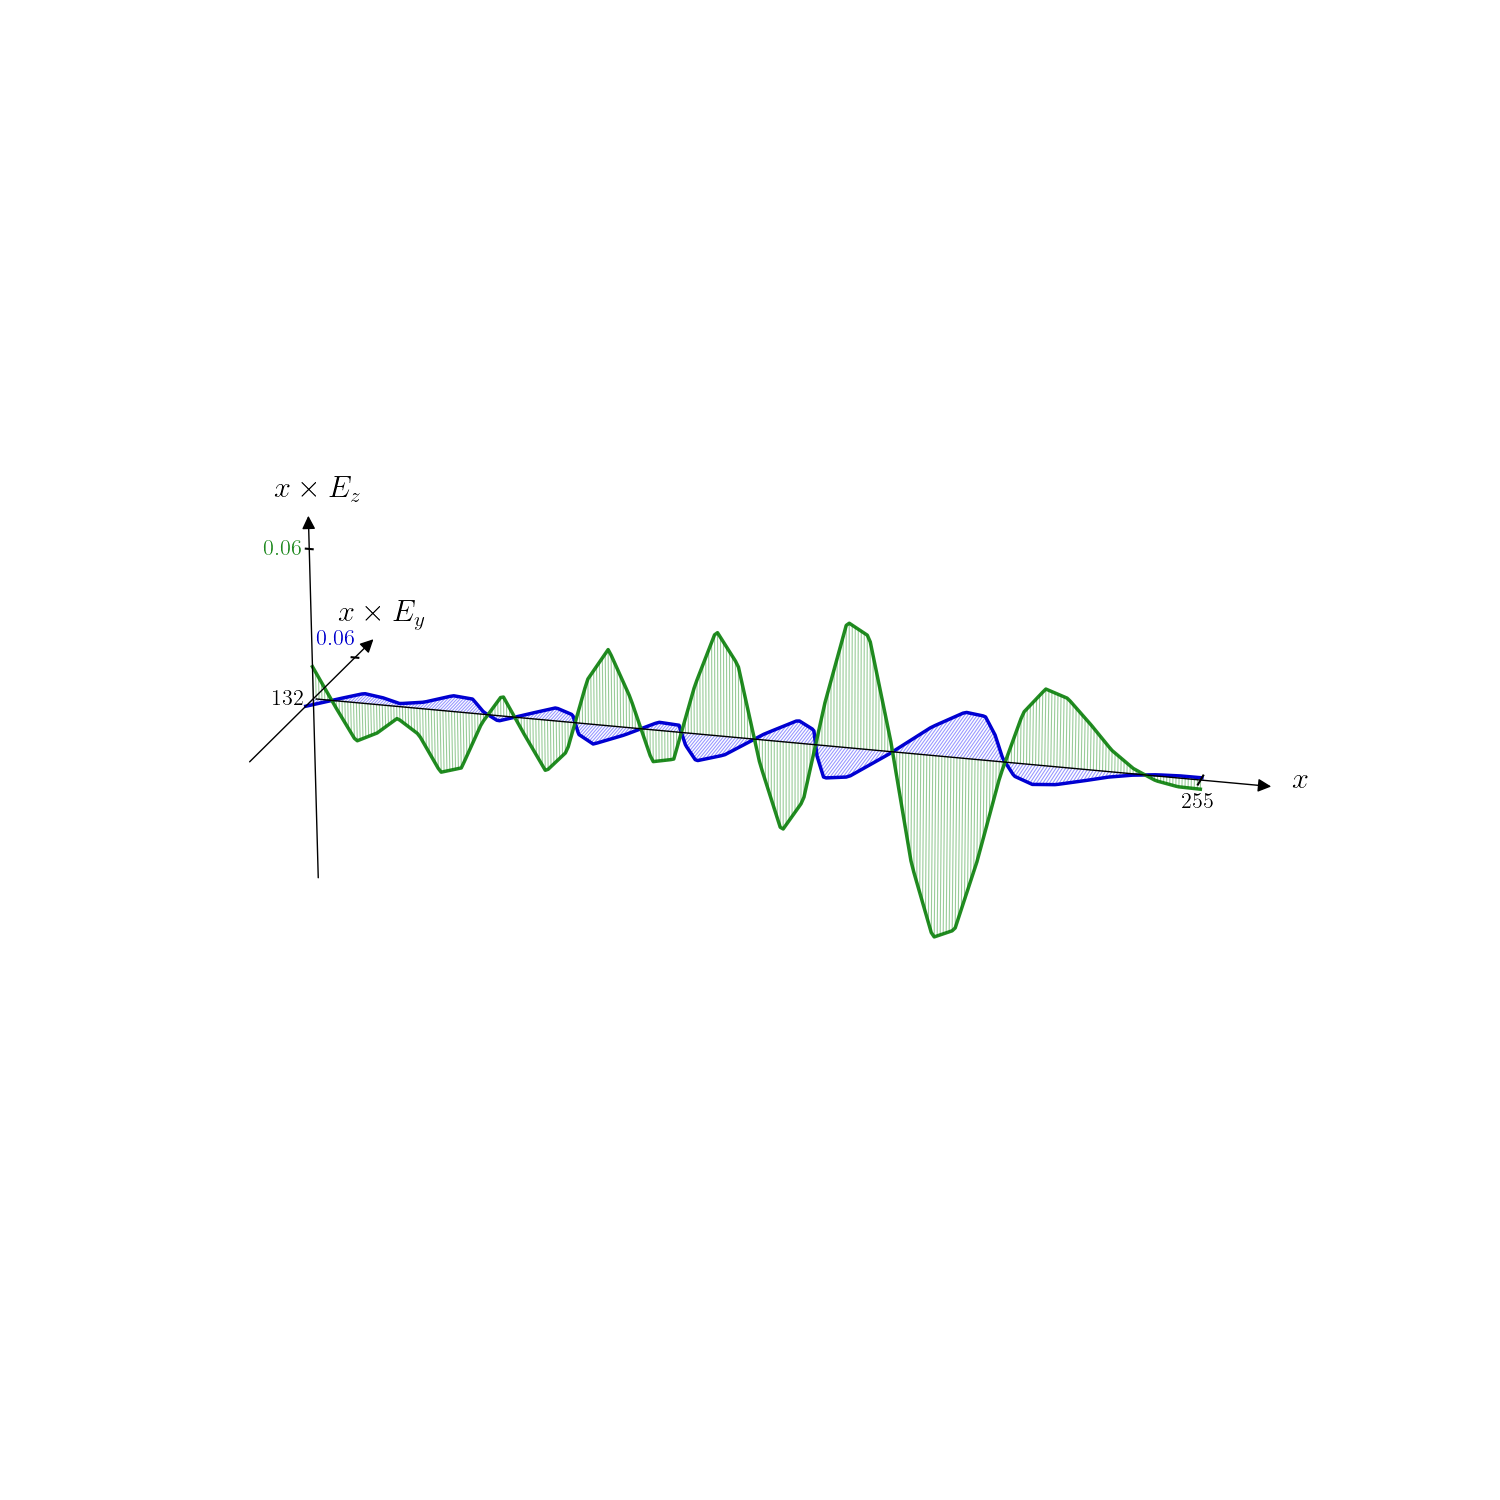

In [ ]:
plt.rcParams.update({
    "text.usetex": True,            # Set to True only if you have a full TeX distribution installed
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",        # 'cm' stands for Computer Modern
})

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return np.min(zs)

# 1. Setup Data
max_range = 8 * np.pi
line = np.linspace(0, max_range, 300)
x_orig = max_range * (coor - coor[0]) / max(coor - coor[0])

y_electric = np.interp(line, x_orig, coor * Ey_electric / max(coor * Ey_electric))
z_magnetic = np.interp(line, x_orig, coor * Ey_mag / max(coor * Ey_mag))

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# 2. Draw Waves
ax.plot(line, y_electric, np.zeros_like(line), color='mediumblue', lw=2.5)
ax.plot(line, np.zeros_like(line), z_magnetic, color='forestgreen', lw=2.5)

# 3. Comb Lines
for i in range(0, len(line), 1):
   ax.plot([line[i], line[i]], [0, y_electric[i]], [0, 0], color='blue', alpha=0.4, lw=0.8)
   ax.plot([line[i], line[i]], [0, 0], [0, z_magnetic[i]], color='green', alpha=0.4, lw=0.8)

# 4. Arrows
prop_len = max_range + 2.0
axis_len = 1.5
arrows = [([0, prop_len], [0, 0], [0, 0]), ([0, 0], [-axis_len, axis_len], [0, 0]), ([0, 0], [0, 0], [-axis_len, axis_len])]

for xs, ys, zs in arrows:
    a = Arrow3D(xs, ys, zs, mutation_scale=20, lw=1, arrowstyle="-|>", color="black")
    ax.add_artist(a)

# --- NEW: Maximum Value Ticks and Labels ---
max_val_x = max_range
max_val_y = np.max(np.abs(y_electric))
max_val_z = np.max(np.abs(z_magnetic))
bar_size = 0.1  # Length of the tick mark

# 1. X-axis tick and label
ax.plot([max_val_x, max_val_x], [-bar_size, bar_size], [0, 0], color='black', lw=1.5)
ax.text(max_val_x, -0.05, -0.2, r"$255$", fontsize=16, ha='center')
ax.text(-0.65, -0.05, -0.05, r"$132$", fontsize=16, ha='center')

# 2. Y-axis tick and label (Tick in the XY plane)
ax.plot([-bar_size, bar_size], [max_val_y, max_val_y], [0, 0], color='black', lw=1.5)
ax.text(0, max_val_y, 0.1, r"$0.06$", fontsize=16, color='mediumblue', ha='right')

# 3. Z-axis tick and label (Tick in the XZ plane)
ax.plot([-bar_size, bar_size], [0, 0], [max_val_z-0.25, max_val_z-0.25], color='black', lw=1.5)
ax.text(-1.5, 0.1, max_val_z-0.4, r"$0.06$", fontsize=16, color='forestgreen', va='bottom')

# 5. Labels (Axis Names)
ax.text(prop_len + 0.5, 0, 0, r"$x$", color='black', fontsize=22)
ax.text(-1.5, axis_len + 0.3, 0, r"$x \times E_y$", color='black', fontsize=22)
ax.text(-1.0, 0, axis_len + 0.1, r"$x \times E_z$", color='black', fontsize=22)

# 6. Final Formatting
ax.set_axis_off()
ax.view_init(elev=20, azim=-75)
ax.set_box_aspect([2.5, 1, 1])

ax.set_xlim(0, prop_len)
ax.set_ylim(-axis_len, axis_len)
ax.set_zlim(-axis_len, axis_len)

plt.show()

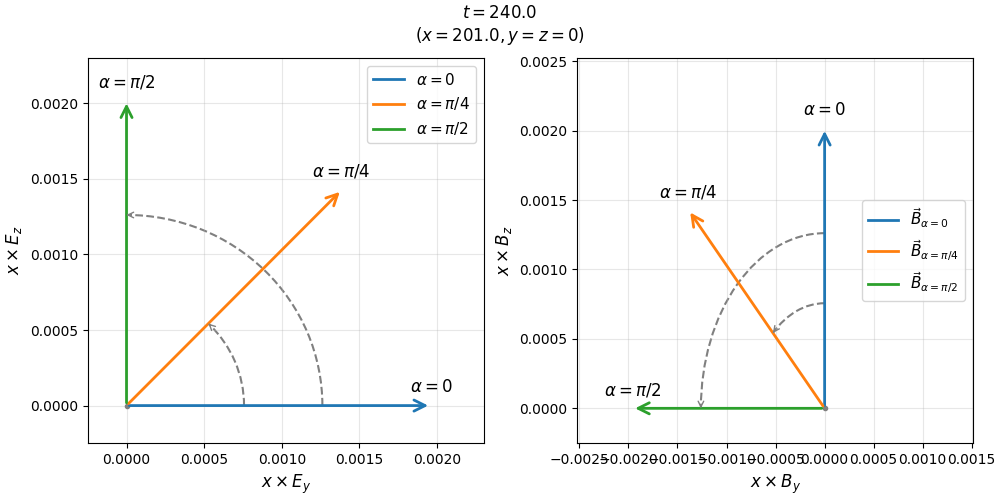

In [116]:
# Helper function to draw vector, text label, and register legend
def draw_vector(ax, y, z, color, label, text, limit):
    # Create a dummy line for the legend
    ax.plot([], [], color=color, lw=2, label=label)

    # Draw the main arrow
    ax.annotate("", xy=(y, z), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2, mutation_scale=20))

    # Add text just above/below the vector head
    ax.text(y, z + (limit*0.025), text, ha='center', va='bottom', fontsize=12)

    # Return angle in degrees for arc drawing
    return np.degrees(np.arctan2(z, y))

# Helper to draw the curved arc between two angles
def draw_angle_arc(ax, radius, theta1, theta2, color):
    t_min, t_max = min(theta1, theta2), max(theta1, theta2)
    arc = Arc((0, 0), radius*2, radius*2, theta1=t_min, theta2=t_max,
              edgecolor=color, lw=1.5, ls='--')
    ax.add_patch(arc)

    # Add an arrowhead to the arc to show rotation direction
    # Placed at the end of the arc (t_max)
    end_theta = np.radians(t_max)
    ax.annotate("", xy=(radius * np.cos(end_theta), radius * np.sin(end_theta)),
                xytext=(radius * np.cos(end_theta-0.01), radius * np.sin(end_theta-0.01)),
                arrowprops=dict(arrowstyle="->", color=color, lw=1))

# --- Data Index & Figure Setup ---
ind = 153
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

plt.suptitle(f"$t = {Ey_electric_gf.time}$\n$(x={coor_gf[ind]}, y=z=0)$")

# Calculate global limit for consistent scaling
limit = max(abs(Ey_electric[ind]), abs(Ez_electric[ind]), abs(By_electric[ind]), abs(Bz_electric[ind]),
            abs(Ey_dyonic[ind]), abs(Ez_dyonic[ind]), abs(By_dyonic[ind]), abs(Bz_dyonic[ind]),
            abs(Ey_mag[ind]), abs(Ez_mag[ind]), abs(By_mag[ind]), abs(Bz_mag[ind]))
limit *= coor_gf[ind]*1.25

# --- Left Plot: Electric Fields ---
ang_e1 = draw_vector(ax1, coor_gf[ind]*Ey_electric[ind], coor_gf[ind]*Ez_electric[ind], "C0", r"$\alpha=0    $", r"$\alpha=0$",     limit)
ang_e2 = draw_vector(ax1, coor_gf[ind]*Ey_dyonic[ind],   coor_gf[ind]*Ez_dyonic[ind],   "C1", r"$\alpha=\pi/4$", r"$\alpha=\pi/4$", limit)
ang_e3 = draw_vector(ax1, coor_gf[ind]*Ey_mag[ind],      coor_gf[ind]*Ez_mag[ind],      "C2", r"$\alpha=\pi/2$", r"$\alpha=\pi/2$", limit)

draw_angle_arc(ax1, limit*0.3, ang_e1, ang_e2, "grey")
draw_angle_arc(ax1, limit*0.5, ang_e1, ang_e3, "grey")

# --- Right Plot: Magnetic Fields ---
ang_b1 = draw_vector(ax2, coor_gf[ind]*By_electric[ind], coor_gf[ind]*Bz_electric[ind], "C0", r"$\vec{B}_{\alpha=0    }$", r"$\alpha=0$",     limit)
ang_b2 = draw_vector(ax2, coor_gf[ind]*By_dyonic[ind],   coor_gf[ind]*Bz_dyonic[ind],   "C1", r"$\vec{B}_{\alpha=\pi/4}$", r"$\alpha=\pi/4$", limit)
ang_b3 = draw_vector(ax2, coor_gf[ind]*By_mag[ind],      coor_gf[ind]*Bz_mag[ind],      "C2", r"$\vec{B}_{\alpha=\pi/2}$", r"$\alpha=\pi/2$", limit)

draw_angle_arc(ax2, limit*0.3, ang_b1, ang_b2,      "grey")
draw_angle_arc(ax2, limit*0.5, ang_b1, abs(ang_b3), "grey")

# --- Final Formatting ---
for ax in [ax1, ax2]:
    ax.plot([0], [0], color="grey", marker="o", markersize=3)
    #ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.1*limit, limit)

#ax1.set_xlim(-0.6*limit, limit)
ax1.set_xlim(-0.00025, 0.0023)
ax1.set_ylim(-0.00025, 0.0023)
ax2.set_xlim(-limit, 0.6*limit)
ax1.legend(loc='upper right',  fontsize=11, framealpha=0.8)
ax2.legend(loc='center right', fontsize=11, framealpha=0.8)

ax1.set_xlabel(r"$x \times E_y$", fontsize=12)
ax1.set_ylabel(r"$x \times E_z$", fontsize=12)
ax2.set_xlabel(r"$x \times B_y$", fontsize=12)
ax2.set_ylabel(r"$x \times B_z$", fontsize=12);

# GWs

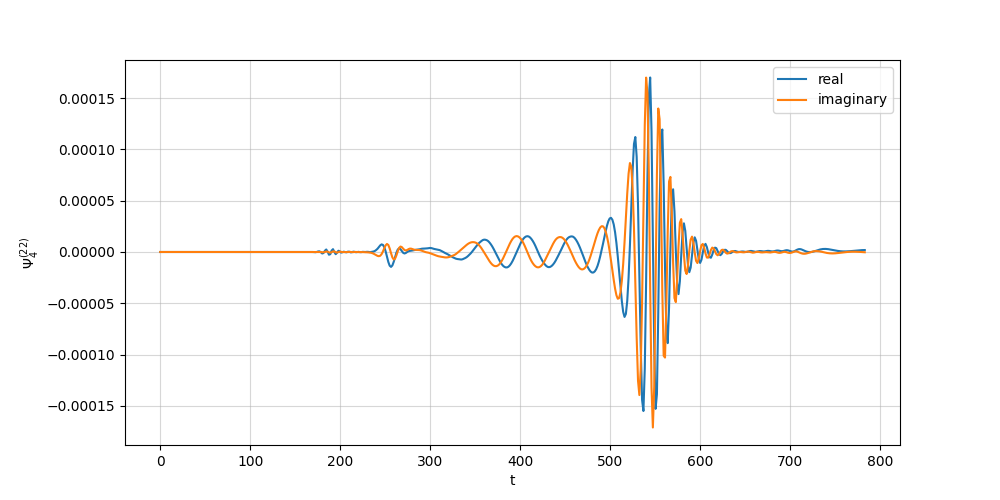

In [55]:
fig, ax1 = plt.subplots(1, 1, figsize=(10,5))

R = 240

psi4_22 = muls_electric["Psi4"][R][(2,2)]

ax1.plot(psi4_22.t, psi4_22.y.real, label="real")
ax1.plot(psi4_22.t, psi4_22.y.imag, label="imaginary")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_ylabel(r"$\Psi_4^{(22)}$")
ax1.legend();

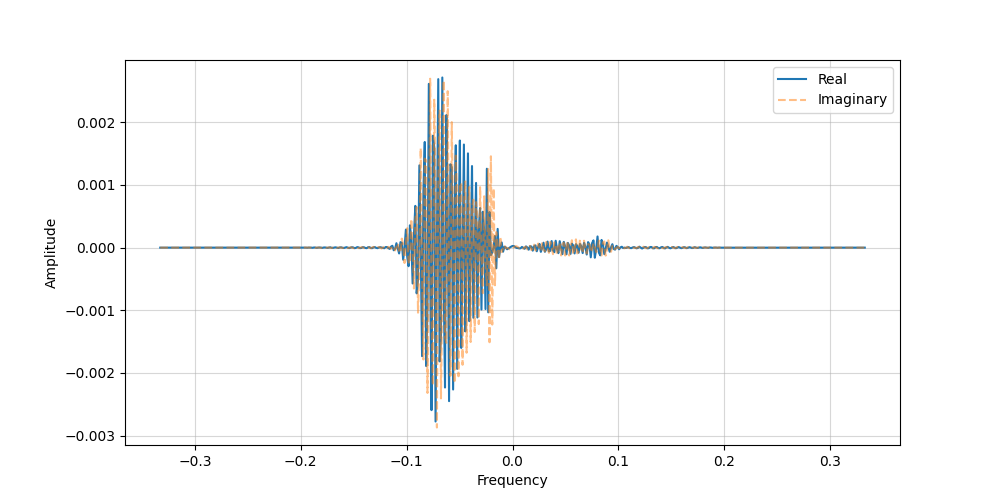

In [7]:
# total number of sampling points
N = len(psi4_22.t)

# coefficientes in frequency domain
freq = np.fft.fftfreq(N, d=psi4_22.t[1]-psi4_22.t[0])

# compute DFT using Hann window function
f1 = np.fft.fft(np.array([np.sin(np.pi*n/(N-1)) for n in range(0, N)]) * psi4_22.y)

# sort output
freq, f1 = zip(*sorted(zip(freq, f1)))
freq = np.array(freq)
f1 = np.array(f1)

fig, ax1 = plt.subplots(1, 1, figsize=(10,5))

ax1.plot(freq, f1.real, color="C0", label="Real")
ax1.plot(freq, f1.imag, color="C1", label="Imaginary", alpha=0.5, linestyle="dashed")

ax1.grid(alpha=0.5)
ax1.set_xlabel("Frequency")
ax1.set_ylabel("Amplitude")
ax1.legend();

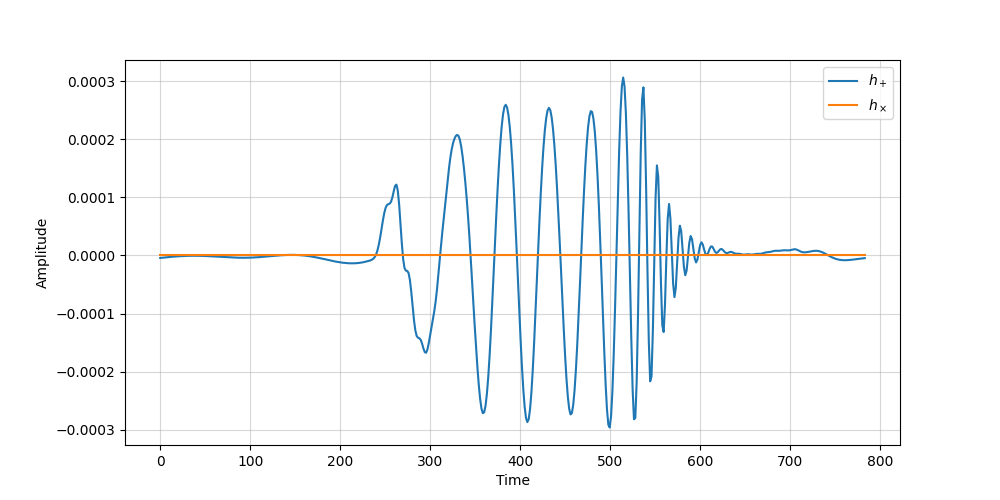

In [23]:
gws = sd_electric.gws
gw_r = gws[R]

# Hann window function
window = lambda N: np.array([np.sin(np.pi*n/(N-1)) for n in range(0, N)])

# theta, phi, period for integration
strain = gw_r.get_strain(np.pi/2,0,100,window_function=window)/R

fig, ax1 = plt.subplots(1, 1, figsize=(10,5))

ax1.plot(strain.x,  strain.y.real, color="C0", label=r"$h_+$")
ax1.plot(strain.x, -strain.y.imag, color="C1", label=r"$h_\times$")

ax1.grid(alpha=0.5)
ax1.set_xlabel("Time")
ax1.set_ylabel("Amplitude")
ax1.legend();

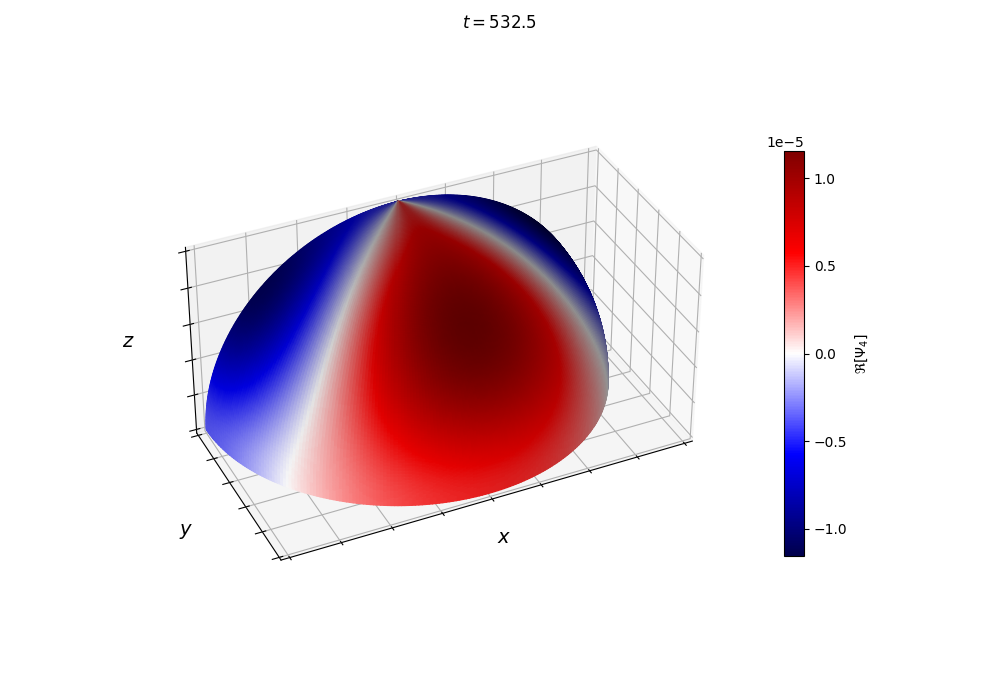

In [56]:
# extraction radius and time indice
R = 240
tind = 355

# current time
t = muls_electric["Psi4"][R][(l, m)].t[tind]

# polar coordinate grid
phi = np.linspace(0, np.pi,     200)
theta = np.linspace(0, np.pi/2, 200)
phi, theta = np.meshgrid(phi, theta)

x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

# compute sum of spin weighted spherical harmonics (raw values)
s = -2
l_min = 2
l_max = 4
fcolors_raw = np.zeros_like(phi)

for l in range(l_min, l_max + 1):
    for m in range(-l, l + 1):
        Y = spheroidal.sphericalY(s, l, m)
        Psi4_lm_real = muls_electric["Psi4"][R][(l, m)].y.real[tind]
        fcolors_raw += Psi4_lm_real * Y(theta, phi).real

# normalization for surface facecolors
fabsmax = max(abs(fcolors_raw.min()), abs(fcolors_raw.max()))
fabsmax = max(fabsmax, 1e-6)
norm = colors.Normalize(vmin=-fabsmax, vmax=fabsmax)
fcolors = norm(fcolors_raw)

# plot
fig = plt.figure(figsize=(10, 7))
plt.suptitle(fr"$t = {t}$")
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=cm.seismic(fcolors))

# color scale
mappable = cm.ScalarMappable(norm=norm, cmap=cm.seismic)
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax, shrink=0.75, pad=0.1)
cbar.set_label(r"$\Re\left[\Psi_4\right]$")

# fancy things up
ax.set_box_aspect([1, 0.5, 0.5])
ax.view_init(elev=35, azim=65)

ax.set_xlim([-1,1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$y$", fontsize=14)
ax.set_zlabel(r"$z$", fontsize=14);

# Sketches

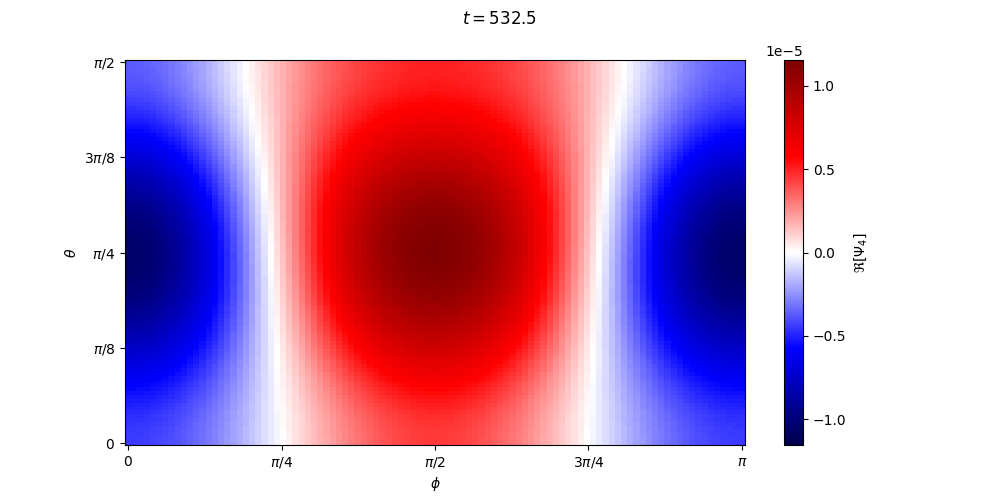

In [ ]:
# extraction radius and time index
R = 240
tind = 355

# current time
t = muls_electric["Psi4"][R][(l, m)].t[tind]

# polar coordinate grid
phi = np.linspace(0,   np.pi,   100)
theta = np.linspace(0, np.pi/2, 100)
phi, theta = np.meshgrid(phi, theta)

# compute sum of spin weighted spherical harmonics
s = -2
l_min = 2
l_max = 4
fcolors_raw = np.zeros_like(phi)

for l in range(l_min, l_max + 1):
    for m in range(-l, l + 1):
        Y = spheroidal.sphericalY(s, l, m)
        Psi4_lm_real = muls_electric["Psi4"][R][(l, m)].y.real[tind]
        fcolors_raw += Psi4_lm_real * Y(theta, phi).real

# normalize colors
fabsmax = max(abs(fcolors_raw.min()), abs(fcolors_raw.max()))
norm = colors.Normalize(vmin=-fabsmax, vmax=fabsmax)
fcolors = norm(fcolors_raw)

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.suptitle(fr"$t = {t}$")

pcm  = ax.pcolormesh(phi, theta, fcolors_raw, cmap=cm.seismic, vmin=-fabsmax, vmax=fabsmax)
cbar = fig.colorbar(pcm, ax=ax)

ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_yticks([0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2])

ax.set_xticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
ax.set_yticklabels([r"$0$", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"])

cbar.set_label(r"$\Re[\Psi_4]$")
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\theta$");

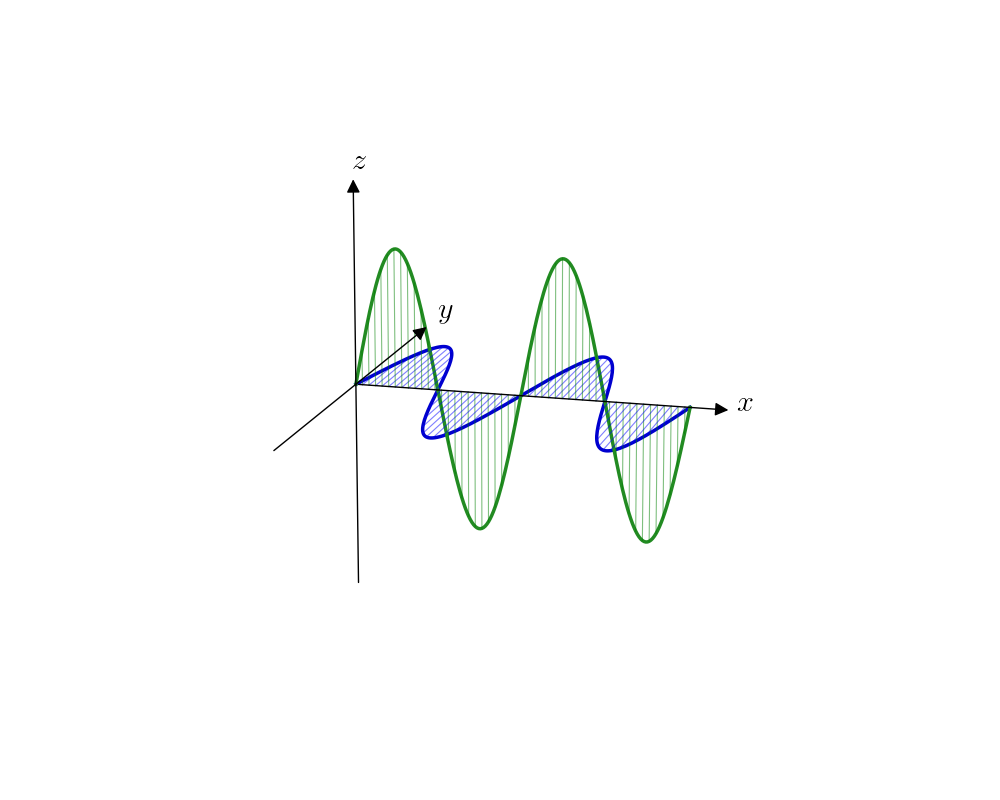

In [5]:
# Helper class to draw 3D arrows
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return np.min(zs)

# 1. Setup Data
x_vals = np.linspace(0, 4 * np.pi, 200)
y_electric = np.sin(x_vals)
z_magnetic = np.sin(x_vals)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Draw the Waves
ax.plot(x_vals, y_electric, np.zeros_like(x_vals), color='mediumblue', lw=2.5)
ax.plot(x_vals, np.zeros_like(x_vals), z_magnetic, color='forestgreen', lw=2.5)

# 3. Add the "Comb" Fill lines
for i in range(0, len(x_vals), 4):
   ax.plot([x_vals[i], x_vals[i]], [0, y_electric[i]], [0, 0], color='blue', alpha=0.5, lw=0.8)
   ax.plot([x_vals[i], x_vals[i]], [0, 0], [0, z_magnetic[i]], color='green', alpha=0.5, lw=0.8)

# 4. Add 3D Arrows for Axes
prop_len = 4 * np.pi + 1.5
axis_len = 1.5

# Arrow definitions: (start_point, end_point)
arrows = [
    ([0, prop_len], [0, 0], [0, 0]),         # x-axis
    ([0, 0], [-axis_len, axis_len], [0, 0]), # y-axis
    ([0, 0], [0, 0], [-axis_len, axis_len])  # z-axis
]

for xs, ys, zs in arrows:
    a = Arrow3D(xs, ys, zs, mutation_scale=20, lw=1, arrowstyle="-|>", color="black")
    ax.add_artist(a)

# 5. Add Labels (Black, LaTeX)
ax.text(prop_len + 0.2, 0, 0, r"$x$", color='black', fontsize=22)
ax.text(0, axis_len + 0.2, 0, r"$y$", color='black', fontsize=22)
ax.text(0, 0, axis_len + 0.05, r"$z$", color='black', fontsize=22)

# 6. Final Formatting
ax.set_axis_off()
ax.view_init(elev=15, azim=-75)

plt.show()